# Probe Guidance Testing and Visualizations

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
import plotly.graph_objects as go
import plotly.io as pio

In [2]:
def plot_6dof_trajectory(positions, orientations, axis_length=0.2, step=5):
    """
    Visualizes a 6 DoF trajectory in Matplotlib.
    
    Parameters:
    - positions: (N, 3) array of [x, y, z]
    - orientations: (N, 3) array of Euler angles [roll, pitch, yaw] in radians 
                    (or pass scipy Rotation objects)
    - axis_length: float, scaling factor for the orientation frame vectors
    - step: int, draw coordinate axes every 'N' steps to avoid clutter
    """
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # 1. Plot the 3D trajectory line
    x, y, z = positions[:, 0], positions[:, 1], positions[:, 2]
    ax.plot(x, y, z, label='Trajectory', color='gray', linestyle='--', linewidth=1.5)
    ax.scatter(x[0], y[0], z[0], color='green', s=50, label='Start')
    ax.scatter(x[-1], y[-1], z[-1], color='red', s=50, label='End')

    # Standard basis vectors in local frame
    local_axes = np.eye(3) * axis_length  # Shape: (3, 3) -> [X, Y, Z]

    # 2. Draw orientation triads along the path
    for i in range(0, len(positions), step):
        pos = positions[i]
        
        # Convert orientation to Rotation Matrix (3x3)
        # Adjust 'xyz' sequence and degrees parameter based on your data format
        rot_matrix = R.from_euler('xyz', orientations[i], degrees=False).as_matrix()
        
        # Rotate local frame axes to world frame
        world_axes = rot_matrix @ local_axes  # Shape: (3, 3)

        # Plot X (Red), Y (Green), Z (Blue) vectors at current position
        colors = ['r', 'g', 'b']
        for col_idx in range(3):
            ax.quiver(
                pos[0], pos[1], pos[2],
                world_axes[0, col_idx], world_axes[1, col_idx], world_axes[2, col_idx],
                color=colors[col_idx], alpha=0.8, linewidth=1.5
            )

    # 3. Formatting & Labels
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    ax.set_title('6 DoF Object Trajectory & Orientation')
    ax.legend()
    
    # Equalize axis aspect ratio so rotations aren't distorted
    ax.set_box_aspect([np.ptp(x), np.ptp(y), np.ptp(z)])

    plt.tight_layout()
    plt.show()

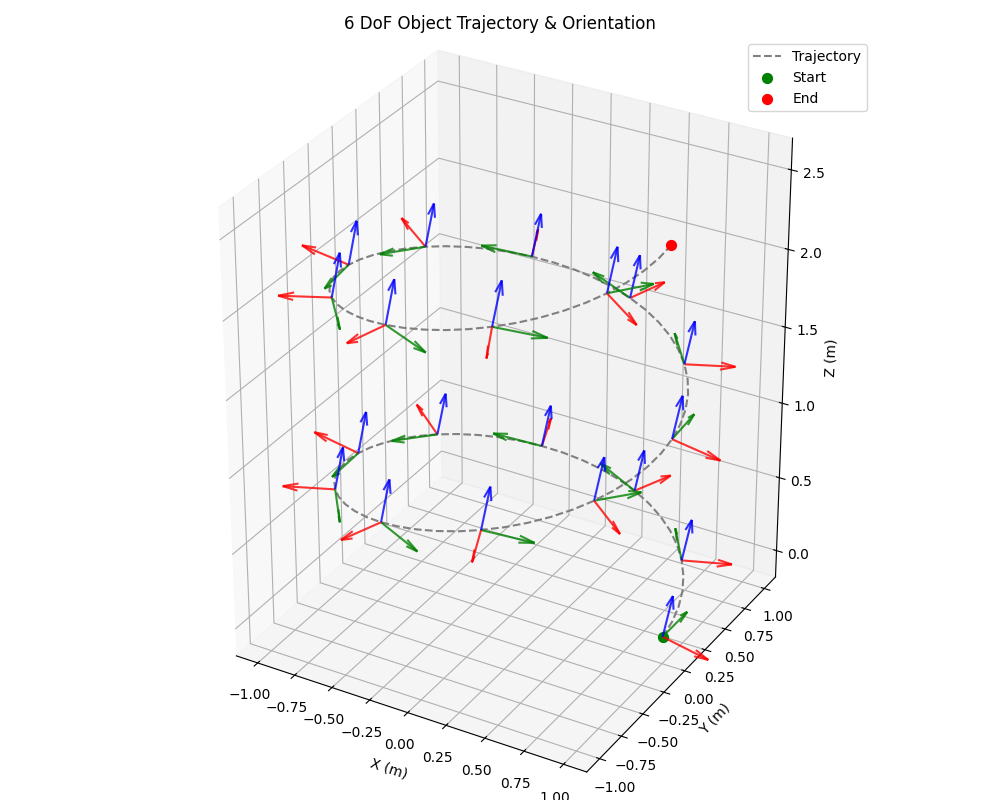

In [3]:
# --- Example Usage with Dummy Spiral Data ---

t = np.linspace(0, 4 * np.pi, 100)

# Positions: spiral upwards
pos_data = np.column_stack([np.cos(t), np.sin(t), t * 0.2])

# Orientations: roll/pitch/yaw turning along the curve
orient_data = np.column_stack([np.sin(t) * 0.2, np.cos(t) * 0.2, t])

# Plotting every 5th frame
plot_6dof_trajectory(pos_data, orient_data, axis_length=0.3, step=5)

In [4]:
# Force Plotly to embed inside an iframe wrapper for JupyterLab/Headless compatibility
pio.renderers.default = "iframe"

def build_3d_animated_trajectory(positions, orientations, axis_length=0.3, step=2):
    n_frames = len(positions)
    local_dirs = np.eye(3) * axis_length
    colors = ['red', 'green', 'blue']

    rot0 = R.from_euler('xyz', orientations[0]).as_matrix()
    dirs0 = rot0 @ local_dirs

    path_trace = go.Scatter3d(
        x=positions[:1, 0], y=positions[:1, 1], z=positions[:1, 2],
        mode='lines', line=dict(color='yellow', width=5), name='Path'
    )

    head_trace = go.Scatter3d(
        x=[positions[0, 0]], y=[positions[0, 1]], z=[positions[0, 2]],
        mode='markers', marker=dict(size=6, color='white'), name='Head'
    )

    arrow_traces = []
    for c_idx in range(3):
        arrow_traces.append(go.Scatter3d(
            x=[positions[0, 0], positions[0, 0] + dirs0[0, c_idx]],
            y=[positions[0, 1], positions[0, 1] + dirs0[1, c_idx]],
            z=[positions[0, 2], positions[0, 2] + dirs0[2, c_idx]],
            mode='lines', line=dict(color=colors[c_idx], width=6),
            name=['X (Forward)', 'Y (Left)', 'Z (Up)'][c_idx]
        ))

    frames = []
    for k in range(0, n_frames, step):
        pos = positions[k]
        rot = R.from_euler('xyz', orientations[k]).as_matrix()
        dirs = rot @ local_dirs

        frame_data = [
            go.Scatter3d(x=positions[:k+1, 0], y=positions[:k+1, 1], z=positions[:k+1, 2]),
            go.Scatter3d(x=[pos[0]], y=[pos[1]], z=[pos[2]]),
        ]

        for c_idx in range(3):
            frame_data.append(go.Scatter3d(
                x=[pos[0], pos[0] + dirs[0, c_idx]],
                y=[pos[1], pos[1] + dirs[1, c_idx]],
                z=[pos[2], pos[2] + dirs[2, c_idx]]
            ))

        frames.append(go.Frame(data=frame_data, name=f'frame_{k}'))

    fig = go.Figure(
        data=[path_trace, head_trace] + arrow_traces,
        layout=go.Layout(
            scene=dict(
                xaxis_title='X (m)', yaxis_title='Y (m)', zaxis_title='Z (m)',
                aspectmode='data'
            ),
            updatemenus=[{
                'type': 'buttons',
                'showactive': False,
                'y': 0, 'x': 0.1, 'xanchor': 'right', 'yanchor': 'top',
                'buttons': [
                    {'label': '▶ Play', 'method': 'animate', 'args': [None, {'frame': {'duration': 30, 'redraw': True}, 'fromcurrent': True}]},
                    {'label': '❚❚ Pause', 'method': 'animate', 'args': [[None], {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate'}]}
                ]
            }],
            sliders=[{
                'steps': [{'args': [[f.name], {'frame': {'duration': 0, 'redraw': True}, 'mode': 'immediate'}],
                           'label': str(idx * step), 'method': 'animate'} for idx, f in enumerate(frames)],
                'x': 0.1, 'len': 0.9, 'y': 0
            }]
        ),
        frames=frames
    )

    return fig

In [5]:
# --- Run ---
t = np.linspace(0, 4 * np.pi, 150)
positions = np.column_stack([np.cos(t), np.sin(t), t * 0.2])
orientations = np.column_stack([np.sin(t) * 0.2, np.cos(t) * 0.2, t])

fig = build_3d_animated_trajectory(positions, orientations, axis_length=0.3, step=2)
fig.show()

Begin with visualizing some dataset examples

In [6]:
from pathlib import Path

dataset_path = "/home/jack/data/probe_guidance_dataset_june"
test_dir = Path(dataset_path) / "test"

episode_paths = [path for path in test_dir.iterdir()]

episode_positions = {}
episode_orientations = {}
for episode_path in episode_paths:
    episode_num = int(str(episode_path).split("/")[-1].split("_")[-1])
    states = np.load(episode_path / "states_6dof.npy")
    states = states[~np.isnan(states).any(axis=1)]
    positions = states[:, :3]
    orientations = states[:, 3:]

    episode_positions[episode_num] = positions
    episode_orientations[episode_num] = orientations

In [7]:
print(f"{episode_positions.keys()=}")

episode_positions.keys()=dict_keys([78, 18, 61, 63, 47, 31, 68])


In [8]:
EPISODE_NUM = 78

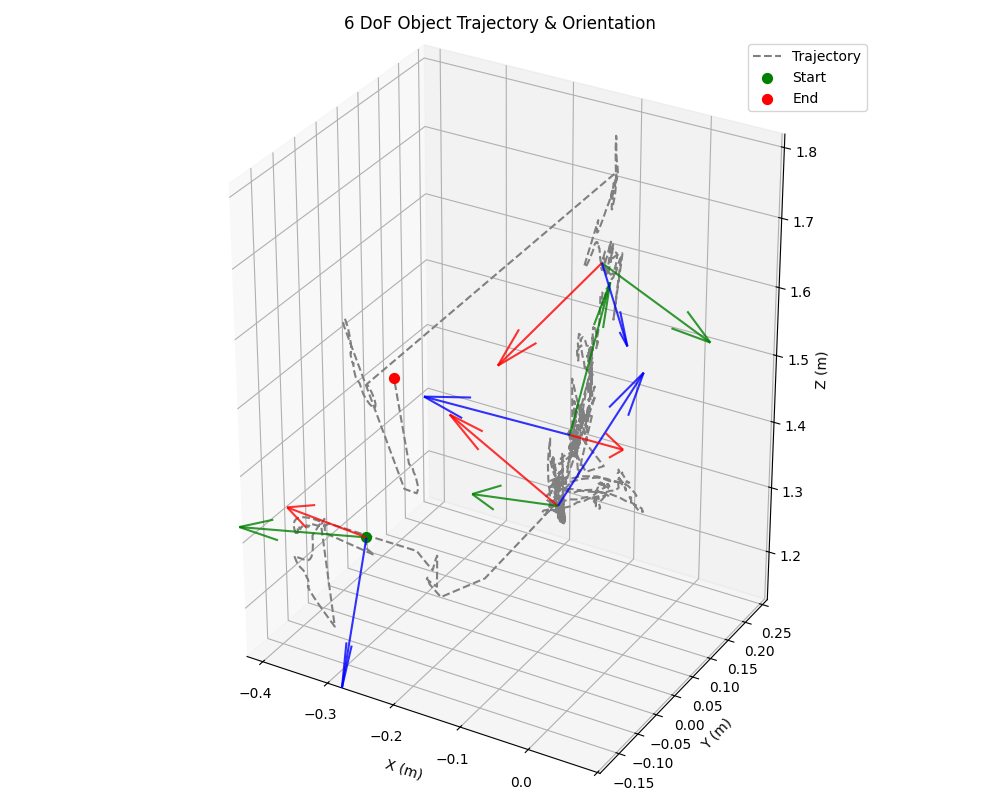

In [9]:
plot_6dof_trajectory(episode_positions[EPISODE_NUM], episode_orientations[EPISODE_NUM], step=500)

In [10]:
fig = build_3d_animated_trajectory(episode_positions[EPISODE_NUM], episode_orientations[EPISODE_NUM], axis_length=0.3, step=2)
fig.show()